In [15]:
# Importing necessary libraries
from scipy import stats 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Generate random numbers from a distribution

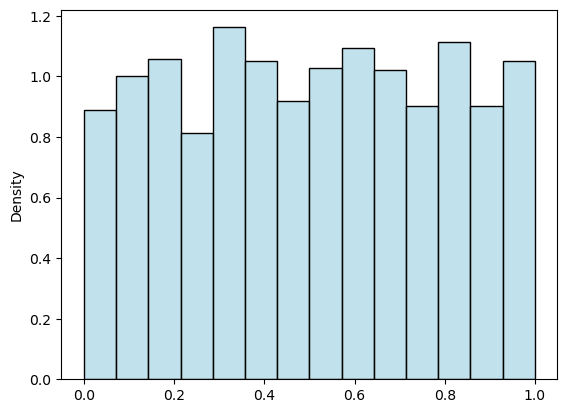

In [16]:
# generate 2000 random numbers from a uniform distribution
x= stats.uniform.rvs(size=2000) # stats.uniform.rvs geenerates random numbers from a uniform distribution
# plot histogram of the data
sns.histplot(x,stat='density', color='lightblue') # sns.histplot creates a histogram of the data with density normalization
plt.show()

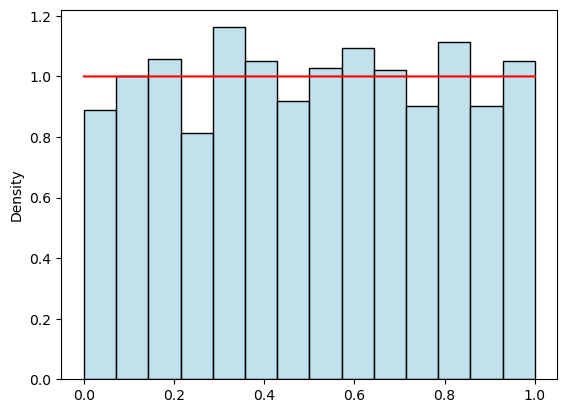

In [17]:
# plot density function to the plot 
sns.histplot(x,stat='density', color='lightblue') 
xvalues = np.linspace(0,1,2000)# generate 2000 evenly spaced numbers between 0 and 1
pdf= stats.uniform.pdf(xvalues) # calculate the probability density function of the uniform distribution
#at the xvalues
plt.plot(xvalues,pdf,color='red') # plot the pdf on the same graph as the histogram
plt.show()

## 2. Monte carlo simulation: Yatzi 

In [18]:
np.random.seed(123) # to make sure tht all answers are aligned
x1= np.random.randint(1,7,size=5) # generate 5 random integers between 1 and 6 
print(x1)

[6 3 5 3 2]


we could then count the number of ones and then count the remaining dice

In [19]:
count_ones1=np.sum(x1==1) # count the number of times 1 appears in x1
x2= np.random.randint(1,7,size=5-count_ones1) # roll remaining dice
print(x2)
count_ones2=np.sum(x2==1) # count the number of times 1 appears in x2
x3= np.random.randint(1,7,size=5-count_ones1-count_ones2) # roll remaining dice again
print(x3)
count_ones3=np.sum(x3==1) # count the number of times 1 appears in x3
score= count_ones1 + count_ones2 + count_ones3 # calculate the total score
print(score)


[4 3 4 2 2]
[1 2 2 1 1]
3


or we simulate the dice roll from a binomial distribition  where, p=1/6 
and n=5 in the first roll 
n-X1 in the second roll
n-X1-X2 in the third roll

In [20]:
# second way to do the same thing 
np.random.seed(321)
from scipy.stats import binom
x1= binom.rvs(n=5, p=1/6, size=1)
x2= binom.rvs(n=5-x1, p=1/6, size=1)
x3= binom.rvs(n=5-x1-x2, p=1/6, size=1)
print('After first roll: ',x1)
print('After second roll: ',x1+x2)
print('After third roll: ',x1+x2+x3)

After first roll:  [2]
After second roll:  [2]
After third roll:  [4]


turning this into a function!!

In [21]:
def play_round(num, n=5, p=1/6):
    x1= binom.rvs(n=5, p=p, size=1)
    x2= binom.rvs(n=5-x1, p=p, size=1)
    x3= binom.rvs(n=5-x1-x2, p=p, size=1)
    return (x1+x2+x3)*num 

In [22]:
print(play_round(1))

[2]


In [23]:
def play_game():
    total_score=0
    for i in range(1,7):
        total_score += play_round(i)
    return total_score
print('Game score: ', play_game())

Game score:  [34]


In [24]:
scores=np.array([play_game() for _ in range(10000)]) 
# simulate 1000 games and store the scores in an array

In [25]:
m=np.mean(scores) # calculate the mean of the scores
print('Expected score: ',m)

Expected score:  44.237


the probability of recieving a bonus (scores>= 63)

In [26]:
bonus_prob = np.mean(scores>= 63) # calculate the probability of getting a score of 63 or higher
print('Expected score: ', bonus_prob)

Expected score:  0.0432


plotting the distribution of the scores

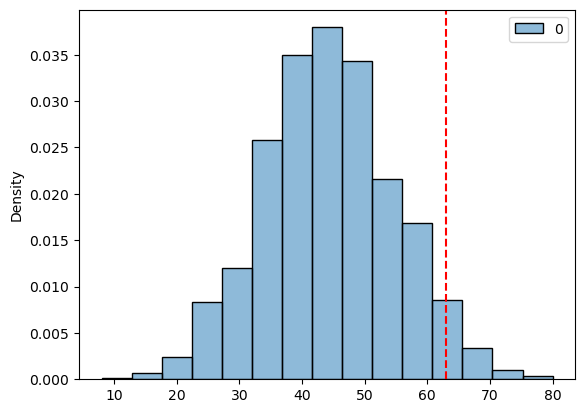

In [27]:
sns.histplot(scores,bins=15,stat='density', color='lightblue')
plt.axvline(63, color='red', linestyle='--')
plt.show()